# Tutorial 2: Evaluate AART and Compare to Direct 1-to-1 Mapping

This notebook loads predictions from Notebook 1 and evaluates:
1. **Per-protein** performance (Pearson r, Spearman, R², RMSE)
2. **Per-sample** performance
3. **AART vs Direct 1-to-1** comparison, stratified by cross-platform concordance

Run `01_train_aart.ipynb` first to generate the `outputs/` directory.

In [27]:
import sys
from pathlib import Path

TUTORIAL_DIR = Path(".").resolve()
PROJECT_ROOT = TUTORIAL_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.models.aart.metrics import (
    build_gene_metrics_table,
    build_sample_metrics_table,
    compute_summary_from_tables,
    gene_corrs,
    sample_corrs,
)

OUTPUT_DIR = TUTORIAL_DIR / "outputs"
DATA_DIR = PROJECT_ROOT / "data" / "CKB"

sns.set_theme(style="whitegrid", font_scale=1.1)
print("Loaded.")

Loaded.


## 1. Load predictions and ground truth

In [28]:
truth_df = pd.read_csv(OUTPUT_DIR / "olink_truth_test.csv")
aart_df = pd.read_csv(OUTPUT_DIR / "aart_predictions_test.csv")
direct_df = pd.read_csv(OUTPUT_DIR / "direct_predictions_test.csv")
anchor_meta = pd.read_csv(OUTPUT_DIR / "anchor_metadata.csv")

gene_names = [c for c in truth_df.columns if c != "csid"]
y_true = truth_df[gene_names].values.astype(np.float32)
y_aart = aart_df[gene_names].values.astype(np.float32)
y_direct = direct_df[gene_names].values.astype(np.float32)
ids = truth_df["csid"].values

print(f"Test samples: {y_true.shape[0]}")
print(f"Proteins:     {y_true.shape[1]}")

Test samples: 796
Proteins:     2168


## 2. Per-protein evaluation

In [29]:
gene_aart = build_gene_metrics_table(y_true, y_aart, gene_names)
gene_direct = build_gene_metrics_table(y_true, y_direct, gene_names)

# Merge into a single comparison table
gene_compare = gene_aart[["protein_symbol", "pearson_r", "spearman_r", "r2", "rmse"]].rename(
    columns=lambda c: f"{c}_aart" if c != "protein_symbol" else c
).merge(
    gene_direct[["protein_symbol", "pearson_r", "spearman_r", "r2", "rmse"]].rename(
        columns=lambda c: f"{c}_direct" if c != "protein_symbol" else c
    ),
    on="protein_symbol",
)
gene_compare["delta_pearson"] = gene_compare["pearson_r_aart"] - gene_compare["pearson_r_direct"]

# Summary statistics
print("Per-protein metrics (median across all proteins):")
print(f"{'':30s} {'AART':>10s} {'Direct 1:1':>10s}")
print(f"{'Pearson r':30s} {gene_aart['pearson_r'].median():10.4f} {gene_direct['pearson_r'].median():10.4f}")
print(f"{'Spearman r':30s} {gene_aart['spearman_r'].median():10.4f} {gene_direct['spearman_r'].median():10.4f}")
print(f"{'R²':30s} {gene_aart['r2'].median():10.4f} {gene_direct['r2'].median():10.4f}")
print(f"{'RMSE':30s} {gene_aart['rmse'].median():10.4f} {gene_direct['rmse'].median():10.4f}")
print(f"\nAART improves over Direct 1:1 in {(gene_compare['delta_pearson'] > 0).sum()} / {len(gene_compare)} proteins")

Per-protein metrics (median across all proteins):
                                     AART Direct 1:1
Pearson r                          0.6840     0.2765
Spearman r                         0.6807     0.3314
R²                                 0.4628     0.0695
RMSE                               0.3934     0.4698

AART improves over Direct 1:1 in 2005 / 2168 proteins


## 3. Per-sample evaluation

In [30]:
sample_r_aart = sample_corrs(y_true, y_aart)
sample_r_direct = sample_corrs(y_true, y_direct)

print("Per-sample Pearson r (across all proteins for each individual):")
print(f"{'':20s} {'AART':>10s} {'Direct 1:1':>10s}")
print(f"{'Median':20s} {np.nanmedian(sample_r_aart):10.4f} {np.nanmedian(sample_r_direct):10.4f}")
print(f"{'Mean':20s} {np.nanmean(sample_r_aart):10.4f} {np.nanmean(sample_r_direct):10.4f}")
print(f"{'Std':20s} {np.nanstd(sample_r_aart):10.4f} {np.nanstd(sample_r_direct):10.4f}")

Per-sample Pearson r (across all proteins for each individual):
                           AART Direct 1:1
Median                   0.8043     0.7419
Mean                     0.7953     0.7290
Std                      0.0672     0.0616


## 4. Distribution of per-protein Pearson r: AART vs Direct 1-to-1

Violin plot comparing the per-protein correlation distribution for both methods.

/tmp/ipykernel_2829790/2865258669.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="method", y="pearson_r", palette=palette,


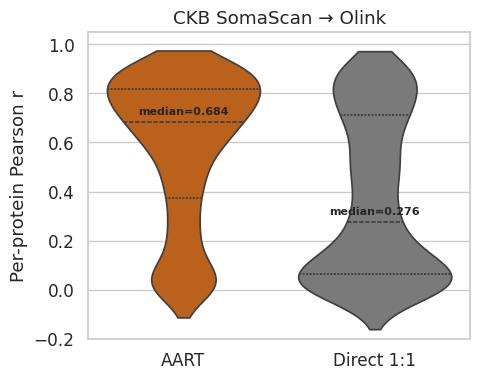

In [31]:
plot_data = pd.concat([
    gene_aart[["protein_symbol", "pearson_r"]].assign(method="AART"),
    gene_direct[["protein_symbol", "pearson_r"]].assign(method="Direct 1:1"),
])

fig, ax = plt.subplots(figsize=(5, 4))
palette = {"AART": "#D55E00", "Direct 1:1": "#7A7A7A"}
sns.violinplot(data=plot_data, x="method", y="pearson_r", palette=palette,
               inner="quartile", cut=0, ax=ax)
ax.set_ylabel("Per-protein Pearson r")
ax.set_xlabel("")
ax.set_ylim(-0.2, 1.05)
ax.set_title("CKB SomaScan → Olink")

# Add median annotations
for i, method in enumerate(["AART", "Direct 1:1"]):
    med = plot_data.loc[plot_data["method"] == method, "pearson_r"].median()
    ax.text(i, med + 0.03, f"median={med:.3f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "violin_aart_vs_direct.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Per-protein scatter: AART vs Direct 1-to-1

Each point is one protein. Points above the diagonal are proteins where AART outperforms Direct 1-to-1.

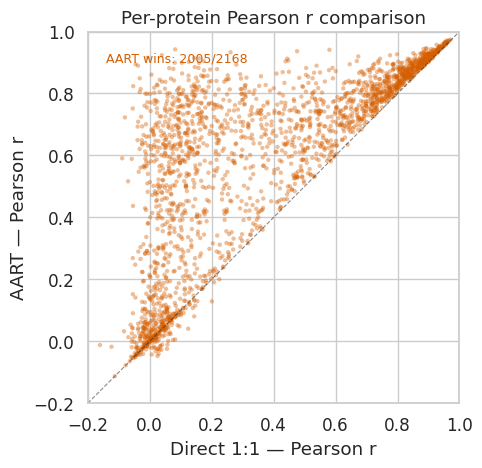

In [32]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gene_compare["pearson_r_direct"], gene_compare["pearson_r_aart"],
           s=10, alpha=0.4, color="#D55E00", edgecolors="none")
ax.plot([-0.2, 1], [-0.2, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("Direct 1:1 — Pearson r")
ax.set_ylabel("AART — Pearson r")
ax.set_xlim(-0.2, 1.0)
ax.set_ylim(-0.2, 1.0)
ax.set_aspect("equal")
ax.set_title("Per-protein Pearson r comparison")

n_above = (gene_compare["delta_pearson"] > 0).sum()
n_total = len(gene_compare)
ax.text(0.05, 0.92, f"AART wins: {n_above}/{n_total}",
        transform=ax.transAxes, fontsize=9, color="#D55E00")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_aart_vs_direct.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Performance stratified by cross-platform concordance

We use the Olink–SomaScan Spearman correlation (ρ) from the Wang et al. mapping table to
stratify proteins into concordance tiers. This is analogous to Figure 1e in the manuscript,
but comparing AART vs Direct 1-to-1 instead of all methods.

Proteins with higher native cross-platform concordance (High ρ) are already well-served
by 1-to-1 mapping. AART's advantage is greatest for proteins with low concordance,
where the residual branch recovers signal beyond what direct mapping can deliver.

In [33]:
# Load the mapping table with cross-platform concordance
from src.models.aart.mapping import canonicalize_symbol

mapping_raw = pd.read_excel(
    DATA_DIR / "41467_2025_56935_MOESM4_ESM.xlsx",
    sheet_name="Supplementary_Data_1",
)

# For each Olink protein, take the max concordance across its SomaScan aptamers
concordance = (
    mapping_raw
    .assign(olink_canonical=lambda df: df["olink_id"].map(canonicalize_symbol))
    .groupby("olink_canonical", sort=False)
    .agg(rho=("rho_olink_soma_ANML", "max"))
    .reset_index()
)

# Merge concordance with per-protein results
gene_compare["protein_canonical"] = gene_compare["protein_symbol"].map(canonicalize_symbol)
stratified = gene_compare.merge(concordance, left_on="protein_canonical", right_on="olink_canonical", how="left")

# Assign concordance tiers — define all categories upfront (including "No mapping")
tier_order = [
    "High\n(ρ > 0.8)",
    "Good\n(0.5 < ρ ≤ 0.8)",
    "Moderate\n(0.2 < ρ ≤ 0.5)",
    "None/Low\n(ρ ≤ 0.2)",
    "No mapping",
]

def assign_tier(rho):
    if pd.isna(rho):
        return "No mapping"
    elif rho > 0.8:
        return "High\n(ρ > 0.8)"
    elif rho > 0.5:
        return "Good\n(0.5 < ρ ≤ 0.8)"
    elif rho > 0.2:
        return "Moderate\n(0.2 < ρ ≤ 0.5)"
    else:
        return "None/Low\n(ρ ≤ 0.2)"

stratified["rho_tier"] = pd.Categorical(
    stratified["rho"].map(assign_tier),
    categories=tier_order,
    ordered=True,
)

tier_counts = stratified["rho_tier"].value_counts().sort_index()
print("Proteins per concordance tier:")
for tier, count in tier_counts.items():
    print(f"  {tier.replace(chr(10), ' ')}: {count}")

Proteins per concordance tier:
  High (ρ > 0.8): 235
  Good (0.5 < ρ ≤ 0.8): 572
  Moderate (0.2 < ρ ≤ 0.5): 380
  None/Low (ρ ≤ 0.2): 981
  No mapping: 0


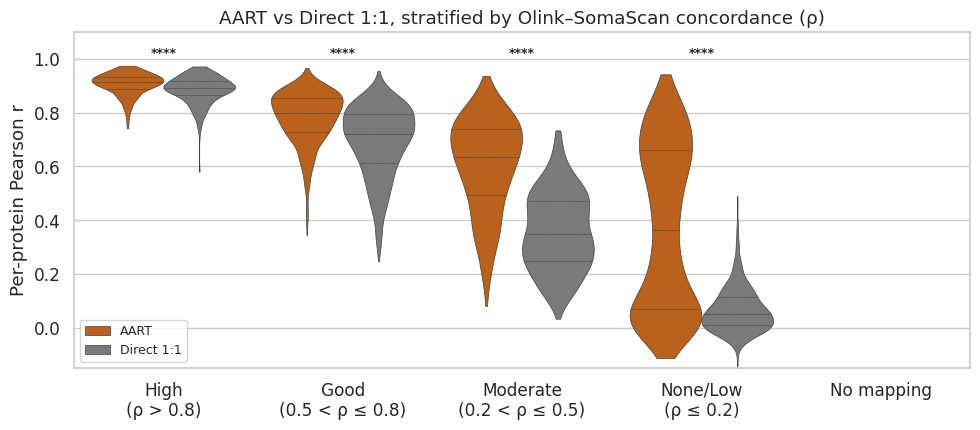

In [34]:
# Build long-form data for violin plot
strat_long = pd.concat([
    stratified[["protein_symbol", "pearson_r_aart", "rho_tier"]].rename(
        columns={"pearson_r_aart": "pearson_r"}).assign(method="AART"),
    stratified[["protein_symbol", "pearson_r_direct", "rho_tier"]].rename(
        columns={"pearson_r_direct": "pearson_r"}).assign(method="Direct 1:1"),
])

palette = {"AART": "#D55E00", "Direct 1:1": "#7A7A7A"}

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.violinplot(
    data=strat_long, x="rho_tier", y="pearson_r", hue="method",
    palette=palette, split=False, inner="quartile", cut=0,
    linewidth=0.5, ax=ax, density_norm="width",
)

# Wilcoxon signed-rank test per tier (AART > Direct 1:1)
for i, tier in enumerate(tier_order):
    sub = stratified[stratified["rho_tier"] == tier]
    if len(sub) < 5:
        continue
    stat_result = stats.wilcoxon(
        sub["pearson_r_aart"], sub["pearson_r_direct"], alternative="greater"
    )
    p = stat_result.pvalue
    stars = "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, 1.01, stars, ha="center", fontsize=9, fontweight="bold")

ax.set_ylim(-0.15, 1.1)
ax.set_xlabel("")
ax.set_ylabel("Per-protein Pearson r")
ax.set_title("AART vs Direct 1:1, stratified by Olink–SomaScan concordance (ρ)")
ax.legend(loc="lower left", frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "violin_stratified_by_concordance.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Per-sample correlation distribution

How well does each individual's full proteome profile get imputed?

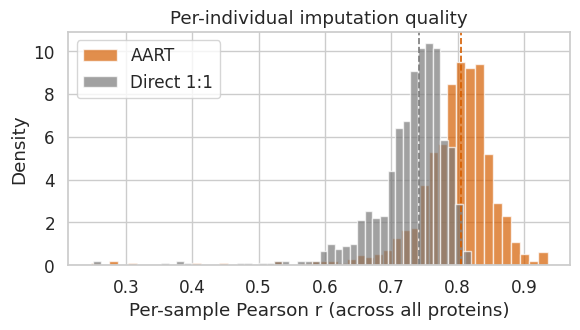

In [35]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(sample_r_aart, bins=50, alpha=0.7, color="#D55E00", label="AART", density=True)
ax.hist(sample_r_direct, bins=50, alpha=0.7, color="#7A7A7A", label="Direct 1:1", density=True)
ax.axvline(np.nanmedian(sample_r_aart), color="#D55E00", ls="--", lw=1.2)
ax.axvline(np.nanmedian(sample_r_direct), color="#7A7A7A", ls="--", lw=1.2)
ax.set_xlabel("Per-sample Pearson r (across all proteins)")
ax.set_ylabel("Density")
ax.set_title("Per-individual imputation quality")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histogram_per_sample.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Summary

Export the full per-protein comparison table.

In [42]:
# Save the per-protein comparison table
export_cols = [
    "protein_symbol", "pearson_r_aart", "pearson_r_direct", "delta_pearson",
    "spearman_r_aart", "spearman_r_direct", "r2_aart", "r2_direct", "rmse_aart", "rmse_direct",
]
gene_compare[export_cols].sort_values("delta_pearson", ascending=False).to_csv(
    OUTPUT_DIR / "per_protein_comparison.csv", index=False
)

print("Top 10 proteins where AART gains the most over Direct 1:1:")
gene_compare.sort_values("delta_pearson", ascending=False).head(10)[
    ["protein_symbol", "pearson_r_aart", "pearson_r_direct", "delta_pearson"]
]

Top 10 proteins where AART gains the most over Direct 1:1:


,protein_symbol,pearson_r_aart,pearson_r_direct,delta_pearson
510,LAT,0.894513,-0.045567,0.940079
788,CCS,0.889774,-0.038012,0.927786
843,ANXA3,0.915481,-0.006961,0.922443
90,EIF4EBP1,0.923775,0.039043,0.884732
1607,NHLRC3,0.848982,-0.032260,0.881242
1073,AARSD1,0.823656,-0.053128,0.876784
946,CA2,0.942423,0.082284,0.860139
621,LTBR,0.860837,0.005739,0.855099
1251,CD27,0.814559,-0.029229,0.843788
1479,GOT1,0.804727,-0.032539,0.837266
